# SECP3223 Group Project - Phase I: Data Preparation and Cleaning

**Course**: Data Analytics Programming  
**Semester**: 2024/2025 Semester 2    

**Group Members**:  
- Joanne Ching Yin Xuan (A23CS0227)  
- Lee Yin Shen (A23CS0236)  
- Lim Yu Han (A23CS0241)  
- Tan Zhi Ming (A23CS0189)    

## ii Do appropriate data cleaning, preparation and wrangling. 

### 1. Import libraries

In [49]:
# Import libraries
# pandas (pd) = for handling table-like data.
# numpy (np) = for doing math and working with arrays.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2. Load the Datasets

In [52]:
# Load fuel data into DataFrame
fuel_df = pd.read_csv("FuelConsumption.csv")

# Load cars 2025 data into DataFrame
cars_df = pd.read_csv("cars_2025.csv")


### 3. Preview Data

In [54]:
# Show first 5 rows of fuel data
print("Fuel Dataset:")
display(fuel_df.head())

print()  

# Show first 5 rows of cars 2025 data
print("Cars 2025 Dataset:")
display(cars_df.head())


Fuel Dataset:


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244



Cars 2025 Dataset:


,date_reg,type,maker,model,colour,fuel,state
0,2025-01-01,motokar,BYD,Seal,white,electric,Rakan Niaga
1,2025-01-01,window_van,Cam,Placer-X,yellow,greendiesel,Johor
2,2025-01-01,jip,Chery,Jaecoo J7,green,petrol,Rakan Niaga
3,2025-01-01,jip,Chery,Jaecoo J7,silver,petrol,Rakan Niaga
4,2025-01-01,jip,Chery,Tiggo,grey,petrol,Rakan Niaga


### 4. Clean and Standardize Data

In [58]:
# Convert both content in MAKE and MODEL column to upper case for fuel dataset.
fuel_df['MAKE'] = fuel_df['MAKE'].str.upper().str.strip()
fuel_df['MODEL'] = fuel_df['MODEL'].str.upper().str.strip()

# Convert both content in maker and model column to upper case for car dataset.
cars_df['maker'] = cars_df['maker'].str.upper().str.strip()
cars_df['model'] = cars_df['model'].str.upper().str.strip()

# Convert the 'type' and 'fuel' column name to uppercase for car dataset.
cars_df.rename(columns={'type': 'TYPE', 'fuel': 'FUEL'}, inplace=True)

# Convert both content in TYPE and FUEL column to upper case for car dataset.
cars_df['TYPE'] = cars_df['TYPE'].str.upper().str.strip()
cars_df['FUEL'] = cars_df['FUEL'].str.upper().str.strip()

### 5. Drop Duplicates and Missing Values

In [60]:
# Drop Duplicates and Missing Values
fuel_df.drop_duplicates(inplace=True)
cars_df.drop_duplicates(inplace=True)

fuel_df.dropna(inplace=True)
cars_df.dropna(inplace=True)

### 6. Drop Unused coloumn

In [63]:
# Drop unused columns from fuel dataset
fuel_df = fuel_df.drop(columns=['MODELYEAR', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB_MPG'])

# Drop unused columns from cars dataset
cars_df = cars_df.drop(columns=['date_reg', 'colour', 'state'])

### 7. Merge both datasets

In [66]:
# Combine car_df and fuel_df where maker and model are the same
# Keep only rows that match in both tables

merged_df = pd.merge(
    cars_df,
    fuel_df,
    left_on=['maker', 'model'],
    right_on=['MAKE', 'MODEL'],
    how='inner'
)

# Preview merged data
display(merged_df.head())

# Drop 'maker' and 'model' column and keep 'MAKE' and 'MODEL' to reduce redunduncy
final_data_cleaned = merged_df.drop(columns=['maker', 'model'])

# Preview the data after dropping redundant columns
display(final_data_cleaned.head())



,TYPE,maker,model,FUEL,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,MOTOKAR,PORSCHE,911 CARRERA,PETROL,PORSCHE,911 CARRERA,MINICOMPACT,3.4,6,AM7,Z,10.1,232
1,MOTOKAR,PORSCHE,911 CARRERA,PETROL,PORSCHE,911 CARRERA,MINICOMPACT,3.4,6,M7,Z,10.7,246
2,MOTOKAR,HONDA,CIVIC,PETROL,HONDA,CIVIC,COMPACT,1.8,4,AV,X,7.0,161
3,MOTOKAR,HONDA,CIVIC,PETROL,HONDA,CIVIC,COMPACT,1.8,4,AV7,X,7.2,166
4,MOTOKAR,HONDA,CIVIC,PETROL,HONDA,CIVIC,COMPACT,1.8,4,M5,X,7.6,175


,TYPE,FUEL,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,MOTOKAR,PETROL,PORSCHE,911 CARRERA,MINICOMPACT,3.4,6,AM7,Z,10.1,232
1,MOTOKAR,PETROL,PORSCHE,911 CARRERA,MINICOMPACT,3.4,6,M7,Z,10.7,246
2,MOTOKAR,PETROL,HONDA,CIVIC,COMPACT,1.8,4,AV,X,7.0,161
3,MOTOKAR,PETROL,HONDA,CIVIC,COMPACT,1.8,4,AV7,X,7.2,166
4,MOTOKAR,PETROL,HONDA,CIVIC,COMPACT,1.8,4,M5,X,7.6,175


### Last. Save cleaned data to CSV 

In [70]:
# Save the dataframe as a tab-separated file
final_data_cleaned.to_csv("cleaned_merged_car_data_2.csv", index=False)


### iii. Do appropriate data aggregation and group operations.

#### 1. Average Carbon Emissions by Car Maker

In [74]:
# Group by Car Maker and calculate the average CO2 emissions
avg_emissions_by_maker = final_data_cleaned.groupby('MAKE')['CO2EMISSIONS'].mean().reset_index()

# Sort the result by CO2 Emissions in descending order
avg_emissions_by_maker.sort_values('CO2EMISSIONS', ascending=False, inplace=True)

# Reset the index to have sequential numbers to see the rank
avg_emissions_by_maker.reset_index(drop=True, inplace=True)

# Display the result
print('1. Average Carbon Emissions by Car Maker\n')
print(avg_emissions_by_maker)


1. Average Carbon Emissions by Car Maker

            MAKE  CO2EMISSIONS
0   ASTON MARTIN    359.000000
1        BENTLEY    348.600000
2       MASERATI    347.000000
3         NISSAN    297.000000
4        PORSCHE    281.244635
5          DODGE    279.500000
6           AUDI    272.281250
7           FORD    266.568627
8          VOLVO    257.320388
9     VOLKSWAGEN    255.923963
10       HYUNDAI    249.205128
11           KIA    245.193548
12        JAGUAR    242.000000
13          JEEP    230.000000
14    LAND ROVER    225.000000
15     CHEVROLET    213.833333
16        SUBARU    208.500000
17         MAZDA    196.610419
18    MITSUBISHI    190.000000
19         HONDA    178.536755
20        TOYOTA    174.318476


#### 2. Average Carbon Emissions by Car Maker

In [77]:
# Group by Car Model and calculate the average CO2 emissions
avg_emissions_by_model = final_data_cleaned.groupby('MODEL')['CO2EMISSIONS'].mean().reset_index()

# Sort the result by CO2 Emissions in descending order
avg_emissions_by_model.sort_values('CO2EMISSIONS', ascending=False, inplace=True)

# Reset the index to have sequential numbers to see the rank
avg_emissions_by_model.reset_index(drop=True, inplace=True)

# Display the result
print('2. Average Carbon Emissions by Car Model\n')
print(avg_emissions_by_model)


2. Average Carbon Emissions by Car Model

                 MODEL  CO2EMISSIONS
0             MULSANNE    437.000000
1                   R8    376.500000
2             VANQUISH    359.000000
3          GRANTURISMO    347.000000
4       CONTINENTAL GT    326.500000
5              911 GT3    322.000000
6                   Q7    304.000000
7                 GT-R    297.000000
8                   S8    297.000000
9              CAYENNE    294.500000
10                 SQ5    292.000000
11                 RS7    290.000000
12                CX-9    283.000000
13             TOUAREG    281.000000
14          CHALLENGER    279.500000
15           911 TURBO    274.000000
16             MUSTANG    267.800000
17            CORVETTE    267.000000
18              SIENNA    260.000000
19                  A8    259.000000
20            SANTA FE    258.000000
21                XC60    258.000000
22              TIGUAN    256.500000
23            PANAMERA    251.000000
24             SORENTO    249.500

#### 3. Average Carbon Emissions by Fuel Type

In [80]:
# Group by Fuel Type and calculate the average CO2 emissions
avg_emissions_by_fuel = final_data_cleaned.groupby('FUELTYPE')['CO2EMISSIONS'].mean().reset_index()

# Sort the result by CO2 Emissions in descending order
avg_emissions_by_fuel.sort_values('CO2EMISSIONS', ascending=False, inplace=True)

# Reset the index to have sequential numbers to see the rank
avg_emissions_by_fuel.reset_index(drop=True, inplace=True)

# Display the result
print('3. Average Carbon Emissions by Fuel Type\n')
print(avg_emissions_by_fuel)


3. Average Carbon Emissions by Fuel Type

  FUELTYPE  CO2EMISSIONS
0        Z    261.929524
1        X    184.072149


### 4. Average Emissions by Engine Size

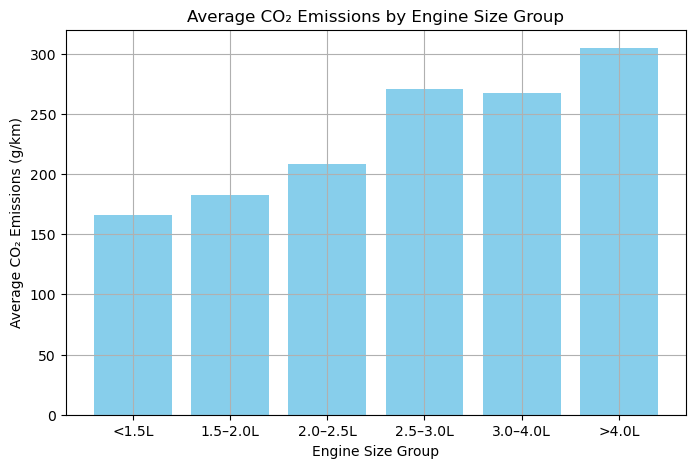

In [87]:
# Bin engine sizes into ranges
engine_bins = [0, 1.5, 2.0, 2.5, 3.0, 4.0, 10.0]
engine_labels = ['<1.5L', '1.5–2.0L', '2.0–2.5L', '2.5–3.0L', '3.0–4.0L', '>4.0L']
final_data_cleaned['EngineSizeGroup'] = pd.cut(final_data_cleaned['ENGINESIZE'], bins=engine_bins, labels=engine_labels)
# Group by engine size group
avg_emissions_by_engine = final_data_cleaned.groupby('EngineSizeGroup', observed=True)['CO2EMISSIONS'].mean().reset_index()


# Plot
plt.figure(figsize=(8,5))
plt.bar(avg_emissions_by_engine['EngineSizeGroup'], avg_emissions_by_engine['CO2EMISSIONS'], color='skyblue')
plt.title("Average CO₂ Emissions by Engine Size Group")
plt.xlabel("Engine Size Group")
plt.ylabel("Average CO₂ Emissions (g/km)")
plt.grid(True)
plt.show()


### 5. Average Emissions by Vehicle Class

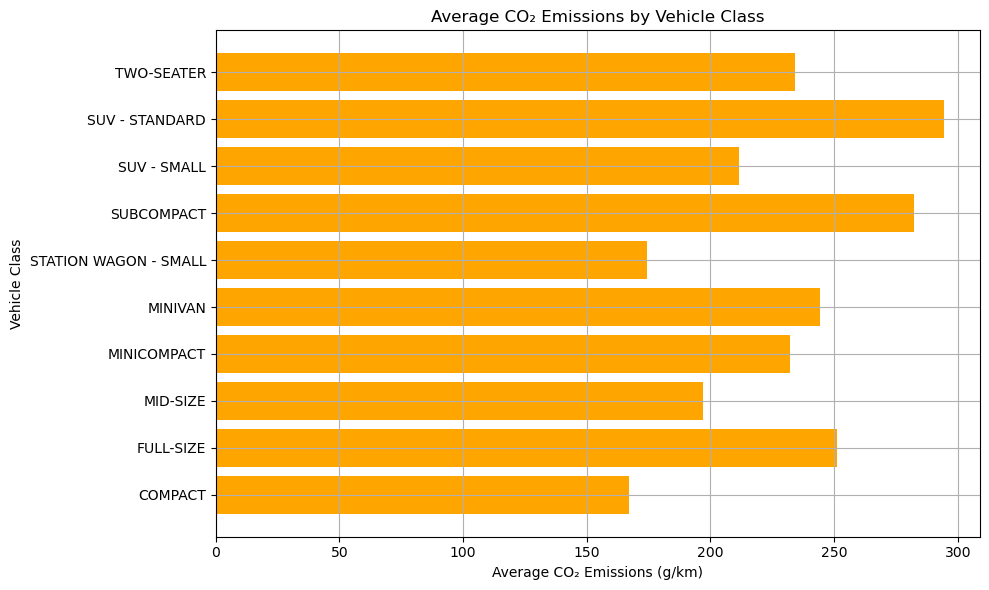

In [92]:
avg_emissions_by_class = final_data_cleaned.groupby('VEHICLECLASS', observed=True)['CO2EMISSIONS'].mean().reset_index()
plt.figure(figsize=(10,6))
plt.barh(avg_emissions_by_class['VEHICLECLASS'], avg_emissions_by_class['CO2EMISSIONS'], color='orange')
plt.title("Average CO₂ Emissions by Vehicle Class")
plt.xlabel("Average CO₂ Emissions (g/km)")
plt.ylabel("Vehicle Class")
plt.grid(True)
plt.tight_layout()
plt.show()

### 6. Average Emissions by Transmission Type

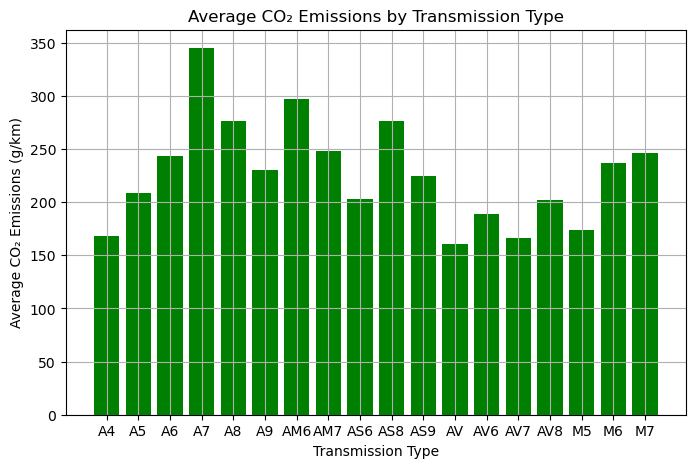

In [94]:
avg_emissions_by_transmission = final_data_cleaned.groupby('TRANSMISSION', observed=True)['CO2EMISSIONS'].mean().reset_index()
plt.figure(figsize=(8,5))
plt.bar(avg_emissions_by_transmission['TRANSMISSION'], avg_emissions_by_transmission['CO2EMISSIONS'], color='green')
plt.title("Average CO₂ Emissions by Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Average CO₂ Emissions (g/km)")
plt.grid(True)
plt.show()